# 两地区 QSM：校准与求解

[在线章节](https://lianxhcn.github.io/qsm101/site/pages/laboratory.html) · [QSM 基础首页](https://lianxhcn.github.io/qsm101/) · [课程主页](https://www.lianxh.cn/qsm.html) · [GitHub 仓库](https://github.com/lianxhcn/qsm101)

本 Notebook 既是在线讲义，也是可以独立运行的练习。它不依赖仓库中的参考程序：模型函数、数据读取、参数估计、校准、均衡求解和核验代码都写在这里。本地存在配套 CSV 时优先读取本地文件；找不到时会从 GitHub 直接读取。

::: {.callout-note title="开始之前" icon=false}

**适合读者：** 已了解回归或因果推断，希望第一次亲手完成空间一般均衡计算的研究者与学生。  
**先修要求：** Python 基础、对数与概率的基本知识；不要求已有结构估计经验。

:::

完成本章后，你应该能够：

- 说明哪些量来自数据，哪些量需要估计、校准或反演；
- 把居民选择、企业工资和住房市场写成一个闭合的两地区模型；
- 估计区位选择敏感度，复原基准均衡并求住房政策反事实；
- 区分局部固定价格计算与完整一般均衡结果；
- 用残差、零冲击、解析解和共同冲击性质检查程序。

**阅读顺序：** 住房政策问题 → 经济设定 → 固定数据 → 参数估计 → 基准反演 → 均衡求解 → 结果解释 → 核验与敏感性分析。

## 1. 从一个住房政策问题开始

经济中只有 A、B 两个地区，共有 10 万个工人。每个工人代表一个只有工资收入的租房家庭，住在哪里就在哪里工作。基准情形如下。

| 变量 | A 地区 | B 地区 |
|---|---:|---:|
| 劳动人口 (人) | 60,000 | 40,000 |
| 月工资 (元/工人) | 10,000 | 8,000 |
| 同质住房月租金 (元/平方米) | 100 | 80 |

这些数值便于计算，未对应任何真实城市。房租表示同等质量住房服务的单位价格，不能与住房售价混用。本文用 $N_{i}$ 表示地区 $i$ 的工人数。因为居住地与工作地相同，基础章节中的居民数 $R_{i}$ 和就业数 $L_{i}$ 在这里满足 $N_{i}=R_{i}=L_{i}$。普通商品可无成本交易；这里没有双边贸易或通勤流量方程。

政府在 B 地区扩建住房，使当地有效住房服务存量增加 20%。如果工资和人口都固定，新增住房会使单位房租从 80 元降至 $80/1.2=66.67$ 元，降幅为 16.67%。但是，较低房租会吸引人口迁入，住房需求随之增加；迁入人口还会改变当地劳动供给，从而影响工资。房租和工资需要重新调整。

因此，我们要计算的是政策实施后同时满足居民选择、劳动市场和住房市场条件的一组数值。这个例子承接两地区空间均衡的基本思路。Redding ([2023](https://doi.org/10.1257/jep.37.2.75)) 介绍了更完整的城市定量模型；本文采用自行构造的教学特例，便于把数据与计算逐项对应。

### 下载配套数据

- [基准人口、工资与租金 CSV](https://raw.githubusercontent.com/lianxhcn/qsm101/main/articles/p04-minimal-qsm/data/teaching-baseline.csv)
- [8,000 条模拟选址任务 CSV](https://raw.githubusercontent.com/lianxhcn/qsm101/main/articles/p04-minimal-qsm/data/synthetic-choice-tasks.csv)

下面的函数依次检查当前目录、仓库根目录和常见下载位置；都找不到时才读取公开网址。需要完全离线运行时，把两个 CSV 放到 Notebook 同目录的 data 子目录。

In [1]:
from pathlib import Path
from urllib.request import urlopen
from io import BytesIO
import hashlib, sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import brentq, minimize
from scipy.special import expit, logsumexp

ALPHA=0.25
BETA=0.90
RAW_BASE="https://raw.githubusercontent.com/lianxhcn/qsm101/main/articles/p04-minimal-qsm/data"

def load_csv(name):
    """优先读取本地固定输入；缺失时读取 GitHub raw 文件。"""
    candidates=[Path("articles/p04-minimal-qsm/data")/name,Path("../../articles/p04-minimal-qsm/data")/name,Path("data")/name,Path(name)]
    for path in candidates:
        if path.is_file():
            payload=path.read_bytes()
            return pd.read_csv(BytesIO(payload)),str(path.resolve()),hashlib.sha256(payload).hexdigest()
    url=f"{RAW_BASE}/{name}"
    with urlopen(url,timeout=30) as response: payload=response.read()
    return pd.read_csv(BytesIO(payload)),url,hashlib.sha256(payload).hexdigest()

baseline_data,baseline_source,baseline_sha=load_csv("teaching-baseline.csv")
choice_data,choice_source,choice_sha=load_csv("synthetic-choice-tasks.csv")
N0=baseline_data["workers"].to_numpy(float)
W0=baseline_data["monthly_wage"].to_numpy(float)
R0=baseline_data["monthly_rent_per_m2"].to_numpy(float)
print(f"Python {sys.version.split()[0]} | numpy {np.__version__} | pandas {pd.__version__}")
print("基准数据：",baseline_source)
print("选址样本：",choice_source)
display(baseline_data)
display(choice_data.head())
assert baseline_sha=="4f85970e3663d4cd94ae56c8ee4f918a11be4e42f750fc5bb74656e982409fd3"
assert choice_sha=="5aaa13d501941242f72f8d936a94843ed909faabc5cc86c92e8eaeaeef009047"
assert np.isclose(N0.sum(),100000)
print("输入校验通过。")

Python 3.12.7 | numpy 1.26.4 | pandas 2.3.3
基准数据： G:\codex_project\github_lianxh\qsm101\articles\p04-minimal-qsm\data\teaching-baseline.csv
选址样本： G:\codex_project\github_lianxh\qsm101\articles\p04-minimal-qsm\data\synthetic-choice-tasks.csv


,region,workers,monthly_wage,monthly_rent_per_m2,origin
0,A,60000.0,10000.0,100.0,teaching_assumption
1,B,40000.0,8000.0,80.0,teaching_assumption


,ln_wage_ratio,ln_rent_ratio,choose_B
0,-0.315674,-0.288119,1
1,-0.065550,-0.313038,1
2,0.086073,-0.312485,1
3,0.303077,0.029176,1
4,-0.288927,-0.186067,0


输入校验通过。


## 2. 把居民、企业与住房市场连接起来

### 2.1 居民选择地区

工人 $n$ 在普通消费 $c$ 和住房服务 $h$ 之间分配工资收入。普通商品的价格归一化为 1，地区 $i\in\{A,B\}$ 的单位房租为 $r_{i}$。设住房支出份额为 $\alpha$，效用和预算约束为：

$$
U_{ni}=\ln B_{i}+(1-\alpha)\ln c+\alpha\ln h+\varepsilon_{ni},\qquad c+r_{i}h=w_{i}.
$$

其中，$B_{i}$ 是地区的居住便利度，$w_{i}$ 是工资，$\varepsilon_{ni}$ 是工人 $n$ 对地区 $i$ 的个人偏好。本文设 $\alpha=0.25$，即居民把工资收入的 25% 用于住房。这里没有储蓄和其他收入，工资收入全部用于消费。

居民给定居住地区后优化消费，可以得到住房需求 $h=\alpha w_{i}/r_{i}$。将最优消费代回效用，去掉各地区共有的常数，地区吸引力可以写为 $\ln B_{i}+\ln w_{i}-\alpha\ln r_{i}$。

如果个人偏好服从独立同分布的 I 型极值分布，尺度为 $1/\theta$，选择地区 $i$ 的人口份额为：

$$
s_{i}=\frac{(B_{i}w_{i}/r_{i}^{\alpha})^{\theta}}{\sum_{j\in\{A,B\}}(B_{j}w_{j}/r_{j}^{\alpha})^{\theta}},\qquad N_{i}=Ns_{i}.
$$

$\theta>0$ 衡量居民对地区吸引力差异的敏感程度。$\theta$ 越大，同样的工资或房租差异引起的人口重新配置越强。即使两个地区工资和房租相同，个人偏好也可以使居民选择不同地区。

这里的 $s_{i}$ 是政策调整结束后的人口份额。模型没有初始居住地和搬迁成本，因此不能直接用它描述逐年的迁移轨迹。

### 2.2 企业决定工资

地区企业使用劳动和固定的非劳动要素生产普通商品。把固定要素吸收到地区生产率 $Z_{i}$ 中，生产函数及竞争性工资为：

$$
Y_{i}=Z_{i}N_{i}^{\beta},\qquad w_{i}=\beta Z_{i}N_{i}^{\beta-1},\qquad 0<\beta<1.
$$

本文设劳动产出弹性 $\beta=0.90$。在其他条件固定时，劳动投入增加 1%，工资约下降 0.10%。居民迁入 B 地区，会增加当地劳动供给；在这个没有生产集聚外部性的模型中，工资随之下降。A 地区人口流出，则会提高留在当地工人的工资。

普通商品可以无成本交易。住房和固定生产要素由区外所有者持有，工人只取得工资收入；区外所有者取得租金和非劳动要素收益，并购买普通商品。这一安排明确了收入归属，也使后面的居民福利计算有清楚的对象。

### 2.3 住房市场决定房租

在每个政策情景中，有效住房服务存量 $H_{i}$ 固定。当地居民的住房支出总额为 $\alpha w_{i}N_{i}$，住房市场出清要求：

$$
r_{i}H_{i}=\alpha w_{i}N_{i},\qquad r_{i}=\frac{\alpha w_{i}N_{i}}{H_{i}}.
$$

住房扩建直接增加 $H_{B}$。居民迁入又增加当地工资总额和住房需求，部分抵消新增供给带来的房租下降。

基础章节用带供给弹性的住房函数介绍一般思路。本文进一步简化，把一个政策情景内的供给弹性设为 0，住房存量 $H_{i}$ 不随租金变化；政策在不同情景之间直接改变存量。居民的住房需求仍会随收入和房租调整。这样的设定便于先看清价格反馈，更完整的模型可以再加入开发商、建设成本和供给弹性。

### 把经济条件写成程序

下面的函数分别对应参数估计、基准反演、给定人口时的价格与选择，以及一维均衡求解。代码完整写在 Notebook 内，不导入仓库中的参考程序。

In [2]:
def estimate_theta(data, alpha=ALPHA):
    """在 alpha 已知时, 用二元 Logit 极大似然估计截距和 theta。"""
    x = data["ln_wage_ratio"].to_numpy() - alpha * data["ln_rent_ratio"].to_numpy()
    X = np.column_stack([np.ones(len(x)), x])
    y = data["choose_B"].to_numpy()

    # logaddexp 避免 exp 溢出; 平均负对数似然改善数值尺度。
    def objective(coef):
        linear = X @ coef
        return np.mean(np.logaddexp(0.0, linear) - y * linear)

    def gradient(coef):
        return X.T @ (expit(X @ coef) - y) / len(y)

    fit = minimize(objective, [0.0, 3.0], jac=gradient, method="L-BFGS-B",
                   bounds=[(None, None), (0.01, 20.0)],
                   options={"ftol": 1e-14, "gtol": 1e-10, "maxiter": 1000})
    score = np.max(np.abs(gradient(fit.x)))
    if not fit.success or score > 1e-7 or not 0.011 < fit.x[1] < 19.99:
        raise RuntimeError(f"MLE 未通过检查: {fit.message}; score={score}")
    p = expit(X @ fit.x)
    information = X.T @ ((p * (1.0 - p))[:, None] * X)
    se = np.sqrt(np.diag(np.linalg.inv(information)))
    estimates = pd.DataFrame({
        "parameter": ["task_intercept", "theta"],
        "true_simulation_value": [0.12, 4.0],
        "estimate": fit.x,
        "iid_standard_error": se,
        "ci95_low": fit.x - 1.96 * se,
        "ci95_high": fit.x + 1.96 * se,
        "data_origin": "synthetic_choice_tasks",
    })
    return float(fit.x[1]), estimates, float(score)


def calibrate(theta, alpha=ALPHA, beta=BETA):
    """固定行为参数后, 从基准人口、工资、租金反演 H、Z 和相对便利度 B。"""
    if not (theta > 0 and 0 < alpha < 1 and 0 < beta <= 1):
        raise ValueError("参数范围不符合本模型")
    # H 为有效住房服务存量; 并非独立观测到的真实建筑面积。
    H = alpha * W0 * N0 / R0
    Z = W0 * N0 ** (1.0 - beta) / beta
    log_B = np.log(N0 / N0.sum()) / theta - np.log(W0) + alpha * np.log(R0)
    log_B -= log_B[0]              # 只识别相对便利度: B_A = 1
    return {"alpha": alpha, "beta": beta, "theta": theta,
            "H": H, "Z": Z, "B": np.exp(log_B)}


def prices_and_choices(log_odds, params, H_hat, Z_hat):
    """给定 log(N_B/N_A), 计算工资、租金以及居民希望选择的份额。"""
    s_B = expit(log_odds)
    N = N0.sum() * np.array([1.0 - s_B, s_B])
    w = W0 * Z_hat * (N / N0) ** (params["beta"] - 1.0)
    H = params["H"] * H_hat
    r = params["alpha"] * w * N / H
    log_v = np.log(params["B"]) + np.log(w) - params["alpha"] * np.log(r)
    scores = params["theta"] * log_v
    desired_shares = np.exp(scores - logsumexp(scores))
    log_welfare_index = logsumexp(scores) / params["theta"]
    return N, w, r, H, desired_shares, log_welfare_index


def solve(params, H_hat=(1.0, 1.0), Z_hat=(1.0, 1.0)):
    """用一维有界求根获得均衡; 不把程序的收敛消息当作经济验证。"""
    H_hat, Z_hat = np.asarray(H_hat, float), np.asarray(Z_hat, float)
    if np.any(H_hat <= 0) or np.any(Z_hat <= 0):
        raise ValueError("政策倍率必须为正")

    def residual(log_odds):
        N, w, r, H, shares, log_V = prices_and_choices(log_odds, params, H_hat, Z_hat)
        # 实际人口比的对数 = 居民选择概率比的对数。
        log_v = np.log(params["B"]) + np.log(w) - params["alpha"] * np.log(r)
        return log_odds - params["theta"] * (log_v[1] - log_v[0])

    root = brentq(residual, -30.0, 30.0, xtol=1e-12)
    N, w, r, H, shares, log_V = prices_and_choices(root, params, H_hat, Z_hat)
    theta, alpha, beta = params["theta"], params["alpha"], params["beta"]
    denominator = 1.0 + theta * (alpha + (1.0 - alpha) * (1.0 - beta))
    # 本特例有解析解, 可独立核验数值求根; 无集聚外部性时残差严格递增。
    analytical_root = np.log(N0[1] / N0[0]) + theta / denominator * (
        alpha * np.log(H_hat[1] / H_hat[0])
        + (1.0 - alpha) * np.log(Z_hat[1] / Z_hat[0]))
    Y = params["Z"] * Z_hat * N ** beta
    checks = {
        "population_total_error": float(abs(N.sum() - N0.sum())),
        "location_choice_error": float(np.max(np.abs(N / N.sum() - shares))),
        "housing_market_relative_error": float(np.max(np.abs(alpha * w * N / r / H - 1.0))),
        "wage_marginal_product_relative_error": float(np.max(np.abs(w / (beta * Y / N) - 1.0))),
        "analytical_log_odds_error": float(abs(root - analytical_root)),
        "root_residual": float(abs(residual(root))),
    }
    if max(checks.values()) > 1e-8:
        raise RuntimeError(f"均衡核验失败: {checks}")
    return {"N": N, "w": w, "r": r, "H": H, "Y": Y,
            "log_welfare_index": float(log_V), "checks": checks}


def report_rows(scenario, state, baseline):
    rows = []
    for i, region in enumerate(["A", "B"]):
        row = {"scenario": scenario, "region": region}
        for key, name in [("N", "workers"), ("w", "monthly_wage"),
                          ("r", "monthly_rent_per_m2"), ("H", "effective_housing_m2")]:
            row[name] = float(state[key][i])
            row[name + "_change_pct"] = float((state[key][i] / baseline[key][i] - 1.0) * 100)
        row["worker_ex_ante_welfare_change_pct"] = float(
            np.expm1(state["log_welfare_index"] - baseline["log_welfare_index"]) * 100)
        rows.append(row)
    return rows

## 3. 数据和参数从哪里来

### 3.1 先确定每个量的用途

QSM 中有些量直接来自数据，有些是行为参数，有些需要在给定参数后由模型反演。把它们放在同一张表中，可以避免把所有量都交给程序自由调整。

| 对象 | 本文的处理 | 真实研究中的信息来源或识别要求 |
|---|---|---|
| $N_{i}^{0}$：基准劳动人口 | 教学设为 6 万、4 万 | 人口普查、就业调查或同一口径的微观样本；本文对象是就业工人，不能直接使用全部常住人口 |
| $w_{i}^{0}$：基准工资 | 教学设为 10,000、8,000 元/月 | 劳动调查、住户调查或劳动工资统计；统一年份、目标群体、税前税后与时间单位 |
| $r_{i}^{0}$：单位租金 | 教学设为 100、80 元/平方米/月 | 租赁合同、租房调查或可核查的租赁数据；需要控制面积与住房质量 |
| $\alpha$：住房支出份额 | 教学设为 0.25 | 住户消费预算或有适用依据的文献参数；本文无储蓄，消费与工资收入相等 |
| $\beta$：劳动产出弹性 | 教学设为 0.90，并做敏感性分析 | 与模型相容的生产函数估计；在相应竞争性 Cobb–Douglas 条件下，也可结合要素收入份额校准 |
| $\theta$：区位选择敏感度 | 在模拟选址样本上估计 | 需要观察备选地区、属性和选择，并有可信的属性变化；两行地区汇总数据不足以识别 |
| $H_{i},Z_{i},B_{i}$：地区特征 | 给定参数后从基准反演 | 可结合独立住房存量数据核查；反演值是依赖模型条件的量 |

国内可以从 [国家统计局的劳动工资统计说明](https://www.stats.gov.cn/zs/tjws/zytjzbqs/dwjyry/202411/t20241128_1957598.html) 和 [CFPS 数据申请入口](https://www.isss.pku.edu.cn/cfps/sjzx/index.htm) 开始整理数据。劳动工资统计有特定覆盖范围，不能把单位就业人员平均工资直接当作全体居民收入。使用 CFPS 时，需要按相应年份的问卷、样本量及公开权限核查实际变量和地理信息。

如果希望练习公开微观数据处理，可以查看美国 [ACS PUMS](https://www.census.gov/programs-surveys/acs/microdata.html)。其公开记录包括个人和住房单元，最细公开地理单元为 PUMA。选择地区边界时应尊重这一层级；住房单元租金也不能在缺少面积和质量信息时直接当作每平方米租金。

住房预算占比与 Cobb–Douglas 偏好的对应，可参见 Davis and Ortalo-Magné ([2011](https://doi.org/10.1016/j.red.2009.12.003))。本文的 0.25 和 0.90 均是教学设定，没有把它们写成该文或某个城市的估计值。

### 3.2 演示一次真正执行的参数估计

::: {.callout-warning title="拟合基准不等于识别" icon=false}

仅有 A、B 两行基准数据时，我们可以在指定 $\theta$ 后调整相对便利度，使模型匹配人口份额。不同的 $\theta$ 配上不同便利度，都可能拟合同一个基准。拟合基准本身不能告诉我们哪个 $\theta$ 正确。

:::

为了展示估计程序，附件生成了 8,000 条假想的二选一任务。每条记录都有 A、B 两个选项的对数工资比、对数房租比和是否选择 B。任务属性随机变化，选择结果按已知模型生成。在 $\alpha=0.25$ 已知时，估计：

$$
\Pr(y_{n}=1)=\Lambda\left[\delta+\theta\left(\ln\frac{w_{Bn}}{w_{An}}-\alpha\ln\frac{r_{Bn}}{r_{An}}\right)\right],\qquad \Lambda(x)=\frac{1}{1+e^{-x}}.
$$

具体的样本生成规则如下。令 $\Delta\ln w_{n}=\ln(w_{Bn}/w_{An})$，$\Delta\ln r_{n}=\ln(r_{Bn}/r_{An})$，分别独立取自以下均匀分布：

$$
\Delta\ln w_{n}\sim\operatorname{Uniform}(-0.35,0.35),\qquad
\Delta\ln r_{n}\sim\operatorname{Uniform}(-0.40,0.40).
$$

再设模拟真值 $\delta=0.12$、$\theta=4$，按上面的概率抽取二元选择 $y_{n}$。参考程序使用 `numpy.random.default_rng(20261004)`，先生成全部 8,000 个工资差，再生成全部房租差，最后抽取全部二元选择。随机数生成器和抽样顺序也是复现约定，不能只记录种子。

程序采用极大似然估计，同时估计 $\delta$ 和 $\theta$，将 $\alpha$ 固定为 0.25。本次得到 $\widehat{\theta}=3.9242$，标准误为 0.1228，估计截距为 0.1337。这个标准误针对独立模拟记录，不是任何真实城市政策预测的标准误。任务截距 $\delta$ 是估计中的干扰参数，不作为地区便利度直接代入均衡模型。

附件还保存了这一份固定样本。第一次让 Codex 独立实现时，直接读取它，比重新随机生成数据更容易判断结果差异来自抽样还是算法。重新生成样本可以作为第二个练习，但要保留生成规则及输入文件的校验值。

真实研究还需要解决工资、租金和未观测便利度之间的内生性，并判断估计样本与政策对象是否相容。可以使用设计合理的选址实验，也可以从实际选址或迁移数据建立识别策略；涉及搬迁成本时，应相应扩展选择模型。附件中的模拟样本只检验估计程序能否恢复已知参数。

### 3.3 把基准数据反演为地区特征

给定 $\alpha$、$\beta$ 和估出的 $\theta$，住房存量及生产率由基准反演：

$$
H_{i}=\frac{\alpha w_{i}^{0}N_{i}^{0}}{r_{i}^{0}},\qquad Z_{i}=\frac{w_{i}^{0}(N_{i}^{0})^{1-\beta}}{\beta}.
$$

代入 A 地区数据，得到 $H_{A}=0.25\times10000\times60000/100=150$ 万平方米；B 地区为 100 万平方米。这两个量是为了匹配基准而反演的有效住房服务存量，未经过独立的实际建筑面积核验。

相对便利度从人口份额反演。令 $B_{A}=1$，则：

$$
\frac{B_{B}}{B_{A}}=\left(\frac{N_{B}^{0}}{N_{A}^{0}}\right)^{1/\theta}\frac{w_{A}^{0}}{w_{B}^{0}}\left(\frac{r_{B}^{0}}{r_{A}^{0}}\right)^{\alpha}.
$$

本次得到 $B_{B}/B_{A}=1.0661$。模型需要用略高的相对便利度，解释 B 地区在工资较低的条件下仍吸引 40% 工人的事实。这个残差还可能吸收遗漏的区位特征和测量误差，不能直接解释为 B 地区公共服务比 A 地区好 6.61%。

### 估计与反演

这里只使用固定的 8,000 条模拟任务。结果出来后同时检查优化器状态与一阶条件，再用估计的 theta 反演有效住房服务、生产率复合项和相对便利度。

In [3]:
theta_hat,estimate_table,mle_score=estimate_theta(choice_data)
display(estimate_table.rename(columns={"parameter":"参数","true_simulation_value":"模拟真值","estimate":"估计值","iid_standard_error":"IID 标准误"})[["参数","模拟真值","估计值","IID 标准误"]].style.format({"模拟真值":"{:.4f}","估计值":"{:.6f}","IID 标准误":"{:.6f}"}))
print(f"一阶条件最大绝对值：{mle_score:.3e}")
params=calibrate(theta_hat)
calibration=pd.DataFrame({"地区":["A","B"],"有效住房服务 H":params["H"],"生产率复合项 Z":params["Z"],"相对便利度 B":params["B"]})
display(calibration.style.format({"有效住房服务 H":"{:,.0f}","生产率复合项 Z":"{:,.4f}","相对便利度 B":"{:.6f}"}))

,参数,模拟真值,估计值,IID 标准误
0,task_intercept,0.1200,0.133674,0.024200
1,theta,4.0000,3.924220,0.122803


一阶条件最大绝对值：3.474e-11


,地区,有效住房服务 H,生产率复合项 Z,相对便利度 B
0,A,"1,500,000","33,386.6324",1.000000
1,B,"1,000,000","25,647.9983",1.066129


估计得到的 $\widehat{\theta}$ 约为 3.9242，接近模拟真值 4。这里能恢复真值，是因为属性变化和选择结果均按已知规则模拟；它只核验估计程序，不能作为任何真实城市的参数证据。

反演得到 $H_A=150$ 万、$H_B=100$ 万平方米，$B_B/B_A\approx1.0661$。这些是让模型复原基准的隐含量。便利度残差还吸收遗漏变量与测量误差，不能直接解释为公共服务差距。

## 4. 用 Codex 把模型变成程序

### 4.1 提供模型约定和验收要求

让 Codex 编写 QSM 程序时，最有用的输入是明确的变量口径、方程和验收要求。可以把长期使用的规则放入项目根目录的 `AGENTS.md`；这是 Codex 官方支持的项目指令机制，参见 [官方说明](https://developers.openai.com/codex/guides/agents-md)。

读者可以选择两条路线。先运行参考程序，能够熟悉输入和输出；再在一个只含模型说明、数据和提示词的练习目录中，让 Codex 独立编写程序，能够检验自己是否把经济设定说清楚。第二条路线应在新的 Codex 会话中进行，避免把已经生成的代码当成输入。

下面这段提示词使用仓库内的固定样本，可以直接交给 Codex。运行环境和输入文件要同时提供。

::: {.callout-note .agent-prompt title="Agent 提示词：生成实现" icon=false}

```text
请用 Python 实现一个两地区 QSM 教学模型。

输入：当前项目的 model.md、data/teaching-baseline.csv 和
data/synthetic-choice-tasks.csv。请先阅读，不读取其他参考实现。
Python 使用 numpy、scipy、pandas；新程序和结果分别写入 code/、results/。

模型约定：总劳动人口 N=100000，基准 A/B 人口为 60000/40000，
工资为 10000/8000 元/工人/月，租金为 100/80 元/平方米/月。
工人住在哪里就在哪里工作，只取得工资收入。普通商品价格为 1；
住房和固定生产要素由区外所有者持有，租金与非劳动要素收益不返还工人。
alpha=0.25，beta=0.90。地区吸引力 V_i=B_i*w_i/r_i**alpha。
居民份额 s_i=V_i**theta/sum(V_j**theta)，N_i=N*s_i。
生产 Y_i=Z_i*N_i**beta，工资 w_i=beta*Z_i*N_i**(beta-1)。
住房市场 r_i*H_i=alpha*w_i*N_i，H_i 在每个政策情景内固定。

固定选址样本为 8000 条模拟任务。令
x=ln_wage_ratio-alpha*ln_rent_ratio，
Pr(choose_B=1)=logistic(delta+theta*x)。同时估计 delta、theta，
保持 alpha 给定，theta 为正，检查极大似然收敛并计算 IID 信息矩阵标准误。
delta 只是任务截距，不能作为地区便利度代入均衡。禁止重新生成或替换输入。

请先说明每个函数对应的方程，然后编写并实际运行代码：
1. 读取固定样本并估计 theta；读取基准人口、工资和租金；
2. H_i=alpha*w_i0*N_i0/r_i0，Z_i=w_i0*N_i0**(1-beta)/beta；
   令 B_A=1，B_B=(N_B0/N_A0)**(1/theta)*(w_A0/w_B0)*(r_B0/r_A0)**alpha；
3. 用 x=log(N_B/N_A) 求居民选择的均衡残差，复原基准；
4. 只把 H_B 乘以 1.20，保留其他基本面和行为参数，求反事实均衡；
5. 计算 W=(sum(V_i**theta))**(1/theta)，报告变化及其福利口径；
6. theta 取 0.5 至 8，beta 取 0.8、0.9、1；每组参数先重新校准基准，
   再实施同一政策。敏感性曲线不作为置信区间；
7. 导出参数、基准与政策结果、敏感性表、核验 JSON 和运行命令。

验收：检查基准复原、零冲击、总人口、选择份额、住房出清和劳动边际产出。
本特例还有解析解：D=1+theta*(alpha+(1-alpha)*(1-beta))，
x1=x0+theta/D*(alpha*log(Hhat_B/Hhat_A)
              +(1-alpha)*log(Zhat_B/Zhat_A))。
各项相对误差或份额误差要求小于 1e-8；解析解与数值解也要对照。
模拟数据只检验程序，不能写成真实城市估计；基准拟合不能代替识别。
若缺少输入或遇到不一致，请说明具体原因，不调整参数来匹配预期结果。
```

:::

这段提示词和固定样本存放在 [配套练习说明](../../articles/p04-minimal-qsm/prompts/README.md) 中。`model.md` 给出完整模型约定，其中包括收入归属、解析解和核验条件。让 Codex 只拿到这些输入，再记录它实际需要哪些补充说明，可以帮助我们改进面向初学者的任务提示。

### 4.2 看清均衡求解器在做什么

这个模型只有一个独立的人口份额。只要知道 $N_{B}$，就知道 $N_{A}=N-N_{B}$，进而可以计算工资和租金，再计算居民希望选择的地区份额。

算法思路很简单：给定一个人口比，计算工资和租金，再用选择公式得到期望人口比；调整人口比，直到实际人口比与期望人口比相等。我们用 $x=\ln(N_{B}/N_{A})$ 表示待求变量，这样计算得到的两地人口始终为正。

以下是附件求解器的核心部分。`params` 已包含前一步校准的参数；代码省略了输入检查和结果导出。

```python
import numpy as np
from scipy.optimize import brentq
from scipy.special import expit


def equilibrium_residual(x, params, housing_multiplier):
    # x 是 B/A 劳动人口比的对数。expit 将它转成 B 地区人口份额。
    share_B = expit(x)
    population = 100000 * np.array([1 - share_B, share_B])

    # 用人口变化计算工资。beta < 1，表示固定要素下劳动边际产出递减。
    base_population = np.array([60000., 40000.])
    base_wage = np.array([10000., 8000.])
    wage = base_wage * (population / base_population) ** (params["beta"] - 1)

    # 住房扩建由 housing_multiplier 指定；新的租金满足住房市场出清。
    housing = params["H"] * housing_multiplier
    rent = params["alpha"] * wage * population / housing

    # 根据当前工资、租金和便利度，计算居民希望形成的人口比。
    log_attractiveness = (
        np.log(params["B"])
        + np.log(wage)
        - params["alpha"] * np.log(rent)
    )
    desired_log_odds = params["theta"] * (
        log_attractiveness[1] - log_attractiveness[0]
    )
    return x - desired_log_odds


# 政策只增加 B 地区住房，A 地区住房保持原值。
housing_multiplier = np.array([1., 1.20])
solution = brentq(
    equilibrium_residual,
    -30., 30.,
    args=(params, housing_multiplier),
)
```

应重点看 `return x - desired_log_odds` 这一行。它要求程序给定的人口比，与居民在相应工资和租金下愿意选择的人口比一致。仅从住房公式算出一个新房租，还没有完成这一步。

### 4.3 运行附件并检查输出

配套仓库按文章组织资料。完成 [Python 环境配置](../../docs/setup.md) 后，在仓库根目录运行：

```text
python -X utf8 -m pip install -r articles/p04-minimal-qsm/requirements.txt
python articles/p04-minimal-qsm/code/qsm_demo.py --output runs/p04-first-run
```

参考程序不调用大模型 API。它会按第 3.2 节的规则生成教学输入，再完成估计、校准和政策计算。生成的输入保存在 `runs/p04-first-run/input/`，结果保存在 `runs/p04-first-run/`。它的主入口用于模拟演示，不读取读者自行替换的数据文件；如需使用真实数据，应另写读取和清理入口，并重新检查识别条件。

结果图需要 Noto Sans CJK SC、微软雅黑或黑体。暂时没有中文字体时，可以先运行：

```text
python articles/p04-minimal-qsm/code/qsm_demo.py --output runs/p04-first-run --no-figures
```

以下文件分别回答不同的问题。

| 文件 | 核对内容 |
|---|---|
| `synthetic-estimates.csv` | 模拟选址样本中的参数估计与标准误 |
| `calibrated-parameters.json` | 给定行为参数后反演的地区基本面 |
| `equilibrium-results.csv` | 基准、住房扩建均衡及固定价格选择预测 |
| `sensitivity-results.csv` | 改变参数、重新校准后的政策结果 |
| `verification.json` | 经济条件残差、软件版本和输入文件校验值 |

在结果表中，`scenario=B_housing_plus20_GE` 的两行是本文的政策均衡。名称含 `NOT_GE` 的两行只是固定价格下的选择预测。仓库保存的 `results/reference/` 用于对照，自己的运行结果写入 `runs/`，便于追溯本次运行使用的输入和环境。

### 直接求基准与政策均衡

下一格求解基准和 B 地住房增加 20% 的新均衡，并重新检查人口、选择份额、住房市场、劳动边际产出与解析解。

In [4]:
baseline=solve(params)
policy=solve(params,H_hat=(1.0,1.20))
rows=report_rows("基准",baseline,baseline)+report_rows("B 地住房增加 20%",policy,baseline)
results=pd.DataFrame(rows)
display(results[["scenario","region","workers","monthly_wage","monthly_rent_per_m2","effective_housing_m2","worker_ex_ante_welfare_change_pct"]].style.format({"workers":"{:,.2f}","monthly_wage":"{:,.2f}","monthly_rent_per_m2":"{:,.3f}","effective_housing_m2":"{:,.0f}","worker_ex_ante_welfare_change_pct":"{:.5f}"}))
print("政策均衡最大核验误差：",f"{max(policy['checks'].values()):.3e}")

,scenario,region,workers,monthly_wage,monthly_rent_per_m2,effective_housing_m2,worker_ex_ante_welfare_change_pct
0,基准,A,"60,000.00","10,000.00",100.000,"1,500,000",0.00000
1,基准,B,"40,000.00","8,000.00",80.000,"1,000,000",0.00000
2,B 地住房增加 20%,A,"58,099.39","10,032.24",97.145,"1,500,000",1.88395
3,B 地住房增加 20%,B,"41,900.61","7,962.95",69.511,"1,200,000",1.88395


政策均衡最大核验误差： 2.331e-15


## 5. 住房扩建后的结果

采用本次估计的 $\widehat{\theta}=3.9242$，并在估计后重新校准地区特征，求得下列反事实均衡。表中结果保留到最接近的整数或两位小数。

| 变量 | A 地区：基准 → 反事实 | B 地区：基准 → 反事实 |
|---|---:|---:|
| 劳动人口 (人) | 60,000 → 58,099 | 40,000 → 41,901 |
| 月工资 (元/工人) | 10,000 → 10,032 | 8,000 → 7,963 |
| 月租金 (元/平方米) | 100 → 97.14 | 80 → 69.51 |
| 有效住房存量 (万平方米) | 150 → 150 | 100 → 120 |

![B 地区住房扩建后，两个地区的人口、工资和租金变化](https://fig-lianxh.oss-cn-shenzhen.aliyuncs.com/qsm-site-fig01-housing-equilibrium-20261005-162814.png)

图示结果来自教学数据的模型计算。B 地区住房增加 20%，其劳动人口增加约 4.75%，月工资下降约 0.46%，单位房租下降约 13.11%。

在政策后的均衡中，B 地区比基准多约 1,901 个工人。模型没有刻画搬迁时间，我们把这项人口重新配置简称为迁入。B 地区的房租降低，吸引居民重新选择地区。当地劳动投入增加，边际产出下降，因此工资略有降低。新增人口提高住房需求，使房租高于工资和人口固定时的 66.67 元。

A 地区也发生了调整。人口流出降低住房需求，单位房租由 100 元降至 97.14 元；当地劳动投入减少，留在当地工人的边际产出提高，月工资由 10,000 元升至约 10,032 元。因此，B 地区住房扩建会影响两地居民面对的工资和租金。

如果先用原工资、原人口计算新增住房对应的租金 66.67 元，再把这项租金和原工资代入选择公式，会预测 B 地区人口增至约 44,359 人。这个预测没有同时重新计算工资和住房需求，不满足全部市场出清条件。完整均衡给出的 41,901 人，可以帮助读者看清价格反馈的作用。

在上述偏好分布下，可以构造工人事前福利指数：

$$
W=\left[\sum_{i\in\{A,B\}}(B_{i}w_{i}/r_{i}^{\alpha})^{\theta}\right]^{1/\theta}.
$$

::: {.callout-warning title="福利指标的解释边界" icon=false}

$\ln W$ 对应工人在区位选择前的期望最大效用，差一个政策前后相同的常数。本次 $W$ 提高约 1.88%。这是全体模型工人在同一选择集合下的事前福利指标，不能读成每个实际居民的收入提高 1.88%。住房建设成本、区外所有者收益变化，以及地区外人口流入均未计入，因此也不能把它当作政策净社会收益。

:::

### 由刚才的结果生成图形

下面的柱长直接来自 policy 与 baseline 两个求解结果。

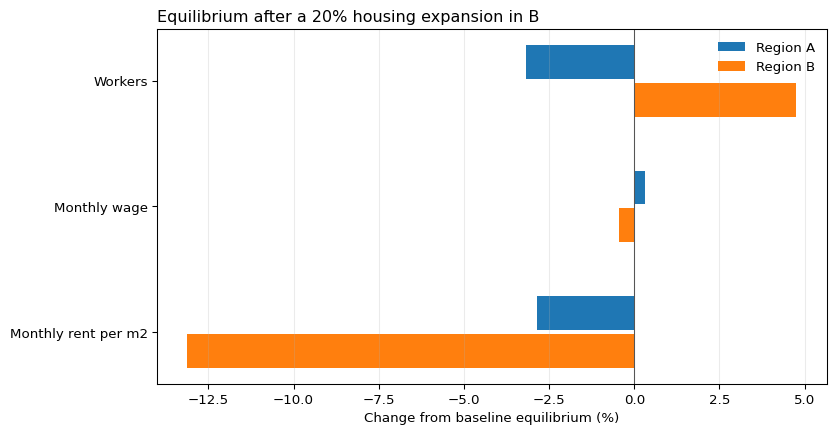

工人事前福利指数变化：1.88395%


In [5]:
labels=["Workers","Monthly wage","Monthly rent per m2"]
keys=["N","w","r"]
changes={region:[(policy[key][i]/baseline[key][i]-1)*100 for key in keys] for i,region in enumerate(["Region A","Region B"])}
y=np.arange(len(labels))
fig,ax=plt.subplots(figsize=(9,4.8))
for j,(region,values) in enumerate(changes.items()): ax.barh(y+(j-0.5)*0.30,values,height=0.27,label=region)
ax.set_yticks(y,labels)
ax.invert_yaxis()
ax.axvline(0,color="#555",linewidth=0.8)
ax.set_xlabel("Change from baseline equilibrium (%)")
ax.set_title("Equilibrium after a 20% housing expansion in B",loc="left")
ax.legend(frameon=False)
ax.grid(axis="x",alpha=0.25)
plt.show()
welfare_change=np.expm1(policy["log_welfare_index"]-baseline["log_welfare_index"])*100
print(f"工人事前福利指数变化：{welfare_change:.5f}%")

## 6. 检查模型结果，再迁移到真实研究

### 6.1 核对经济条件

程序已经检查了基准复原、零政策冲击、人口总量、居民选择、住房市场和工资边际产出条件。基准数据在本次运行中得到复原，反事实条件的数值残差小于 $10^{-8}$。这个特例还有解析解，附件把解析结果与数值求根逐项核对。

这些检查针对本次执行的参考程序，回答的是程序是否实现了给定模型。地区特征本来就是由基准反演出来的，所以匹配基准不能作为模型在样本外成立的证据。真实研究还应检验独立数据、实际政策变化或没有被校准使用的结果。

可以把下面这段核验提示词交给 Codex。

::: {.callout-note .agent-prompt title="Agent 提示词：核验结果" icon=false}

```text
请核验现有 QSM 程序，不改变模型设定。
逐项检查：人口总量、居民选择概率、工资等于劳动边际产出、住房出清。
验证零冲击返回基准，并把数值结果与本模型的解析解对照。
把两个地区住房同时增加 20%，检查人口份额和工资是否保持不变，
两地租金是否同除以 1.20，工人福利指数是否同乘以 1.20**alpha。
指出哪些结果由设定直接决定，哪些仍需要真实数据验证。
再把两个地区生产率同时乘以 1.10，检查人口份额是否不变、工资与租金
是否同乘以 1.10、福利指数是否同乘以 1.10**(1-alpha)。
保存实际运行命令、输入校验值、环境版本和残差。
发现不一致时定位方程或代码，不要通过调整参数消除差异。
```

:::

### 6.2 改变参数时重新校准

我们还改变 $\theta$ 和 $\beta$，比较同一住房政策下 B 地区的人口增幅。每组参数都重新反演地区特征，以便复原同一份基准数据。

![选择敏感度和生产函数劳动弹性变化时，B 地区人口增幅的变化](https://fig-lianxh.oss-cn-shenzhen.aliyuncs.com/qsm-site-fig02-housing-sensitivity-20261005-162814.png)

图中的横轴是区位选择敏感度 $\theta$，三条线对应不同的劳动产出弹性 $\beta$。$\theta$ 越大，居民越容易响应房租下降；$\beta$ 越接近 1，迁入带来的工资下降越弱，B 地区吸引的人口越多。这些曲线是参数情景比较，不是统计置信区间。

这个两地区特例可以解析求解，因而适合检查 Codex 实现的程序。它没有通勤、搬迁成本、失业、住房质量差异和集聚外部性。进入真实研究时，需要围绕实际政策逐项增加必要机制，并保留可复核的数据口径、参数依据和市场出清检查。

### 6.3 从本地试跑中补充使用提示

复现参考代码，与按提示词独立写出代码，是两项不同练习。前者检查程序在自己的环境中能否运行；后者检查模型说明和提示词是否足以指导 Agent 完成工作。配套任务书要求在新会话中保留输入、原始提示词、实际运行命令和结果，再将经过定位、修改与复测的问题写入使用说明。

2026-10-05，原始提示词在独立目录和桌面版 Codex 新会话中完成了实际实现与运行。固定输入未改，模拟样本的估计值为 $\hat\theta=3.924220149$，IID 标准误为 0.122802775；B 地区住房增加 20% 后，人口为 41,900.6076 人，月工资为 7,962.9494 元，月租金为 69.5109 元/平方米，工人事前福利指数提高 1.88395%。基准、零冲击、市场出清、边际产出、解析解、共同冲击和 231 组敏感性检查均通过，最大误差为 $2.99\times10^{-14}$，低于 $10^{-8}$。这些是模拟教学结果，不代表真实城市政策收益。

实际试跑先遇到两类工具环境问题：旧版 Codex CLI 0.144.6 默认模型在执行前返回版本兼容错误，显式指定另一个模型又返回账号不支持；改用桌面版新会话后，默认 Windows 沙箱启动命令失败。该会话按环境补充改用授权执行，随后读取同一份固定输入、独立编写程序并复测通过。实现提示词本身没有改动；补充的是执行环境处理方法。

本地参考复现中，pip 24.0 按 GBK 读取带中文注释的 UTF-8 依赖文件，触发 `UnicodeDecodeError`。使用 `python -X utf8 -m pip install -r articles/p04-minimal-qsm/requirements.txt` 后安装成功，依赖一致性与参考数值复测均通过。这是已验证的环境处理方法。独立实现使用另一 Python 3.11.14 环境，numpy 2.4.2、scipy 1.15.3、pandas 2.3.3；数值对照在任务书容差内。

### 6.4 下一篇加入通勤引力方程

本文让居住地与工作地相同，可以先用一维求根看清校准和价格反馈。下一篇计划允许工人住在 B 地区、到 A 地区工作，用居住地—工作地组合的选择形成通勤流量，并引入通勤成本及相应的引力关系。

届时，居民数决定住房需求，就业数决定劳动边际产出，二者需要分开统计和求解。继续使用“B 地区住房增加 20%”这一政策问题，可以比较新增通勤机制如何改变就业、居住和房租的调整。后续通勤扩展需要自己的通勤数据约定、参数校准及重新计算的结果；本文数值不能直接沿用。

### 固定价格计算与一般均衡

如果只代入机械房租降幅，人口会增加得更多，因为工资和新增住房需求还没有反馈回来。

In [6]:
fixed_rent=R0/np.array([1.0,1.2])
fixed_scores=theta_hat*(np.log(params["B"])+np.log(W0)-ALPHA*np.log(fixed_rent))
fixed_population=N0.sum()*np.exp(fixed_scores-logsumexp(fixed_scores))
comparison=pd.DataFrame({"计算":["固定工资与机械房租（非一般均衡）","工资、房租和人口共同调整（一般均衡）"],"B 地人口":[fixed_population[1],policy["N"][1]],"B 地人口增幅 (%)":[(fixed_population[1]/N0[1]-1)*100,(policy["N"][1]/N0[1]-1)*100],"B 地房租":[fixed_rent[1],policy["r"][1]]})
display(comparison.style.format({"B 地人口":"{:,.1f}","B 地人口增幅 (%)":"{:.3f}","B 地房租":"{:.3f}"}))

,计算,B 地人口,B 地人口增幅 (%),B 地房租
0,固定工资与机械房租（非一般均衡）,"44,359.2",10.898,66.667
1,工资、房租和人口共同调整（一般均衡）,"41,900.6",4.752,69.511


### 敏感性分析与独立性质检查

改变 theta 或 beta 时，每组参数都重新反演地区特征。曲线是参数情景比较，并非统计置信区间。随后再检查两个有明确答案的共同冲击。

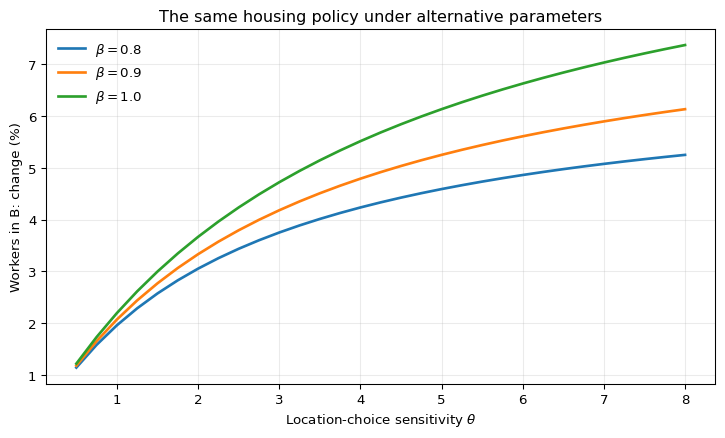

基准复原、共同住房冲击、共同生产率冲击：全部通过。


In [7]:
grid=np.linspace(0.5,8.0,31)
records=[]
for beta in [0.8,0.9,1.0]:
    for theta in grid:
        p=calibrate(theta,beta=beta)
        b=solve(p)
        cf=solve(p,H_hat=(1.0,1.2))
        records.append({"theta":theta,"beta":beta,"B workers change (%)":(cf["N"][1]/b["N"][1]-1)*100})
sensitivity=pd.DataFrame(records)
fig,ax=plt.subplots(figsize=(9,4.8))
for beta,g in sensitivity.groupby("beta"): ax.plot(g["theta"],g["B workers change (%)"],linewidth=2,label=fr"$\beta={beta:.1f}$")
ax.set(xlabel=r"Location-choice sensitivity $\theta$",ylabel="Workers in B: change (%)",title="The same housing policy under alternative parameters")
ax.grid(alpha=0.25); ax.legend(frameon=False); plt.show()

common_housing=solve(params,H_hat=(1.2,1.2))
common_productivity=solve(params,Z_hat=(1.1,1.1))
np.testing.assert_allclose(baseline["N"],N0,rtol=1e-10)
np.testing.assert_allclose(baseline["w"],W0,rtol=1e-10)
np.testing.assert_allclose(baseline["r"],R0,rtol=1e-10)
np.testing.assert_allclose(common_housing["N"],baseline["N"],rtol=1e-10)
np.testing.assert_allclose(common_housing["w"],baseline["w"],rtol=1e-10)
np.testing.assert_allclose(common_housing["r"],baseline["r"]/1.2,rtol=1e-10)
np.testing.assert_allclose(common_productivity["N"],baseline["N"],rtol=1e-10)
np.testing.assert_allclose(common_productivity["w"],baseline["w"]*1.1,rtol=1e-10)
np.testing.assert_allclose(common_productivity["r"],baseline["r"]*1.1,rtol=1e-10)
print("基准复原、共同住房冲击、共同生产率冲击：全部通过。")

## 练习：把住房扩建改成 10%

把 B 地住房倍率从 1.20 改为 1.10，重新计算 B 地人口、工资、房租和福利指数。先写下方向预测，再运行代码。比较固定价格计算与一般均衡结果之间的差距是否缩小。

下面保留一个答案脚手架。把 None 替换为政策倍率；运行后检查最大误差仍小于 $10^{-8}$。

In [8]:
exercise_multiplier=None
if exercise_multiplier is None:
    print("请先填写 B 地住房倍率，再运行本格。")
else:
    exercise=solve(params,H_hat=(1.0,exercise_multiplier))
    display(pd.DataFrame(report_rows("练习",exercise,baseline)))
    print("最大核验误差：",max(exercise["checks"].values()))

请先填写 B 地住房倍率，再运行本格。


## 7. 参考资料

- Redding, S. J. (2023). Quantitative urban models: From theory to data. *Journal of Economic Perspectives*, 37(2), 75–98. [Link](https://doi.org/10.1257/jep.37.2.75), [PDF](https://www.princeton.edu/~reddings/pubpapers/JEP-Urban-2023.pdf), [Google](https://scholar.google.com/scholar?q=Quantitative+Urban+Models+From+Theory+to+Data).
- Davis, M. A., & Ortalo-Magné, F. (2011). Household expenditures, wages, rents. *Review of Economic Dynamics*, 14(2), 248–261. [Link](https://doi.org/10.1016/j.red.2009.12.003), [Google](https://scholar.google.com/scholar?q=Household+Expenditures+Wages+Rents).
- U.S. Census Bureau. ACS Public Use Microdata Sample (PUMS). [数据与说明](https://www.census.gov/programs-surveys/acs/microdata.html).
- 北京大学中国社会科学调查中心. 中国家庭追踪调查 (CFPS). [数据申请与说明](https://www.isss.pku.edu.cn/cfps/sjzx/index.htm).
- 国家统计局. 单位就业人员平均工资的计算方法. [统计口径说明](https://www.stats.gov.cn/zs/tjws/zytjzbqs/dwjyry/202411/t20241128_1957598.html).
- OpenAI. Custom instructions with AGENTS.md. [官方说明](https://developers.openai.com/codex/guides/agents-md).

## 下载、复用与后续扩展

- [下载本 Notebook](https://github.com/lianxhcn/qsm101/raw/main/site/pages/laboratory.ipynb)
- [下载基准数据](https://raw.githubusercontent.com/lianxhcn/qsm101/main/articles/p04-minimal-qsm/data/teaching-baseline.csv)
- [下载模拟选址任务](https://raw.githubusercontent.com/lianxhcn/qsm101/main/articles/p04-minimal-qsm/data/synthetic-choice-tasks.csv)
- [查看完整模型约定](https://github.com/lianxhcn/qsm101/blob/main/articles/p04-minimal-qsm/model.md)
- [查看原始 Codex 提示词](https://github.com/lianxhcn/qsm101/tree/main/articles/p04-minimal-qsm/prompts)
- [查看参考程序](https://github.com/lianxhcn/qsm101/blob/main/articles/p04-minimal-qsm/code/qsm_demo.py)

常见问题：

- 本地数据路径不同时，可以把 CSV 放进 Notebook 同目录的 data 文件夹，或保持联网让程序读取 GitHub raw 文件。
- Windows 遇到 UTF-8 依赖文件读取错误时，可使用 Python 的 UTF-8 模式安装依赖。
- 字体警告不影响数值。中文标签显示为方框时，可安装微软雅黑或 Noto Sans CJK SC。
- 求解器报告成功只说明达到停止条件。仍须核对居民选择、总人口、住房市场、工资条件、零冲击和解析解。

下一章将把居住地与工作地分开，加入通勤成本和双边流量。它会沿用本章写法：背景和方程之后立即进入数据、代码、结果与核验，并提供独立可运行的 Notebook。完成前，本站只保留规划，不预先填写未经计算的结果。